<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/Lab1_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Implement a matrix factorisation using gradient descent

In [ ]:
from typing import Tuple
import torch

def sgd_factorise(A: torch.Tensor, rank: int, epochs=1000, lr=0.01) -> Tuple[torch.Tensor, torch.Tensor]:

  m, n = A.shape

  U = torch.randn(m, rank)
  V = torch.randn(n, rank)

  for epoch in range(epochs):
    for i in range(n):
      E = A[:,i] - U @ V[i,:].t()
      U = U + E.unsqueeze(1) * V[i,:] * lr

    for i in range(m):
      E = A[i,:] - U[i,:] @ V.t()
      V = V + E.unsqueeze(1) * U[i,:] * lr

    # for r in range(m):
    #   for c in range(n):
    #     e = A[r,c] - U[r,:] @ V[c,:].t()
    #     U[r,:] = U[r,:] + lr * e * V[c,:]
    #     V[c,:] = V[c,:] + lr * e * U[r,:]

  return U, V

A = torch.tensor([
    [3.3359, 0.0492, 1.8374],
    [0.3374, 0.6005, 0.1735],
    [2.9407, 0.5301, 2.2620]
])

U_pred, V_pred = sgd_factorise(A, 2)

loss_pred = torch.nn.functional.mse_loss(U_pred @ V_pred.t(), A, reduction='sum')
print(f"reconstruction loss: {loss_pred}")


reconstruction loss: 0.12468701601028442


# 2 Compare your result to truncated SVD

In [ ]:
U, S, V = torch.svd(A)
S[2] = 0

D = torch.diag(S)

loss_svd = torch.nn.functional.mse_loss(U @ D @ V.t(), A, reduction='sum')

print(loss_svd)

tensor(0.1219)


# 3 Matrix completion

In [ ]:
def sgd_factorise_mask(A: torch.Tensor, M: torch.Tensor, rank: int, epochs=1000, lr=0.01) -> Tuple[torch.Tensor, torch.Tensor]:
  m, n = A.shape

  U = torch.randn(m, rank)
  V = torch.randn(n, rank)

  for epoch in range(epochs):
    for i in range(n):
      E = (A[:,i] - U @ V[i,:].t()) * M[:,i]
      U = U + E.unsqueeze(1) * V[i,:] * lr

    for i in range(m):
      E = (A[i,:] - U[i,:] @ V.t()) * M[i,:]
      V = V + E.unsqueeze(1) * U[i,:] * lr

  return U, V


A = torch.tensor([[0.3374, 0.6005, 0.1735],
                  [0,      0.0492, 1.8374],
                  [2.9407, 0,      2.2620]])
M = torch.tensor([[1, 1, 1],
                  [0, 1, 1],
                  [1, 0, 1]])

U, V = sgd_factorise_mask(A, M, rank=2)

print(U @ V.t())

tensor([[ 0.3373,  0.6007,  0.1736],
        [ 2.4626,  0.0491,  1.8373],
        [ 2.9407, -0.4593,  2.2620]])


# 4 Movie Recommendation

In [ ]:
def gd_factorise_masked(A: torch.Tensor, M: torch.Tensor, rank: int, epochs=1000, lr: float=1e-5) -> Tuple[torch.Tensor, torch.Tensor]:
  m, n = A.shape

  U = torch.randn(m, rank, device=A.device, dtype=A.dtype)
  V = torch.randn(n, rank, device=A.device, dtype=A.dtype)

  loss = []

  for epoch in range(epochs):
    E = (A - U @ V.t()) * M
    U = U + E @ V * lr
    V = V + E.t() @ U * lr

    loss.append(torch.sum(E*E).cpu())

  return U, V, loss

In [ ]:
!wget 'http://ecs-vlc.github.io/COMP6258/labs/lab1/ratings.pt'

URL transformed to HTTPS due to an HSTS policy
--2026-02-14 11:46:32--  https://ecs-vlc.github.io/COMP6258/labs/lab1/ratings.pt
Resolving ecs-vlc.github.io (ecs-vlc.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to ecs-vlc.github.io (ecs-vlc.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40000747 (38M) [application/octet-stream]
Saving to: ‘ratings.pt.2’

ratings.pt.2        100%[===================>]  38.15M  --.-KB/s    in 0.07s   

2026-02-14 11:46:35 (585 MB/s) - ‘ratings.pt.2’ saved [40000747/40000747]



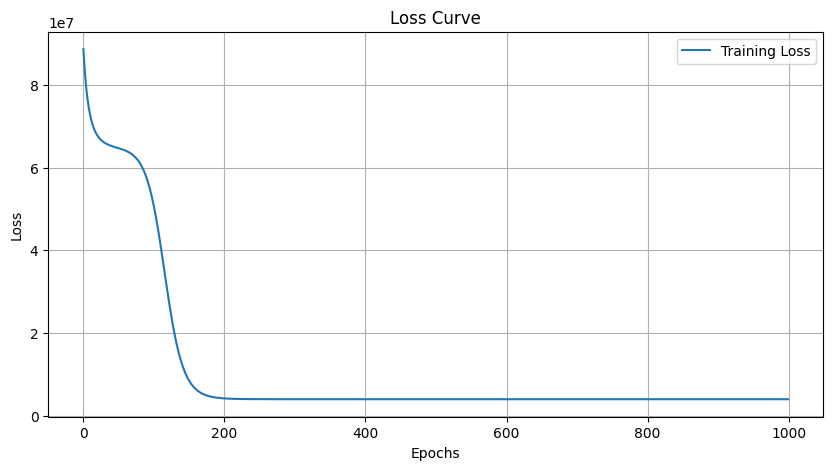

In [ ]:
device = torch.device("cuda")

A = torch.load('ratings.pt').to(device)
M = (A != 0).float().to(device)

U, V, loss_history = gd_factorise_masked(A, M, rank=5)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Prepare movie titles
!wget http://ecs-vlc.github.io/COMP6258/labs/lab1/titles.csv

import csv

movie2name = {}
name2movie = {}

with open('titles.csv', 'r') as file:
    reader = csv.DictReader(file)

    for row in reader:
        movie2name[int(row['movie'])] = row['name']
        name2movie[row['name']] = int(row['movie'])

In [ ]:
movie_id = name2movie["A Beautiful Mind"]

# predict the user's rating
rating_pred = U[movie_id,:] @ V[4,:].t()

print(f"movie_id: {movie_id}")
print(f"rating: {rating_pred}")

In [ ]:
A_pred = (U @ V.t()) * M
sse = torch.nn.functional.mse_loss(A_pred, A, reduction='sum')
print(sse)

tensor(3940933., device='cuda:0')
tensor(3940933., device='cuda:0')


In [ ]:
A_pred.shape